In [2]:
!pip install yfinance

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.6 MB 289.3 kB/s eta 0:00:04
   ------------ --------------------------- 0.5/1.6 MB 289.3 kB/s eta 0:00:04
   ------------------- -------------------- 0.8/1.6 MB 421.0 kB/s eta 0:00:02
   -------------------------------------- -

  DEPRECATION: Building 'multitasking' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'multitasking'. Discussion can be found at https://github.com/pypa/pip/issues/6334


In [1]:
import pandas as pd 
import numpy as np 
import yfinance as yf 

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
#Cross Sectional Model

# S&P 500 Tickers List (as of February 2026)
sp500_tickers = [
    'NVDA', 'AAPL', 'MSFT', 'AMZN', 'GOOGL', 'GOOG', 'META', 'TSLA', 'AVGO', 'BRK.B',
    'WMT', 'LLY', 'JPM', 'XOM', 'V', 'JNJ', 'MU', 'MA', 'ORCL', 'COST',
    'ABBV', 'HD', 'BAC', 'PG', 'CVX', 'CAT', 'KO', 'AMD', 'GE', 'NFLX',
    'PLTR', 'CSCO', 'MRK', 'LRCX', 'PM', 'AMAT', 'GS', 'MS', 'WFC', 'RTX',
    'UNH', 'IBM', 'TMUS', 'INTC', 'MCD', 'AXP', 'PEP', 'LIN', 'GEV', 'VZ',
    'TXN', 'T', 'AMGN', 'ABT', 'NEE', 'C', 'GILD', 'KLAC', 'BA', 'TMO',
    'DIS', 'APH', 'ANET', 'CRM', 'ISRG', 'TJX', 'SCHW', 'BLK', 'ADI', 'DE',
    'LOW', 'PFE', 'UNP', 'HON', 'ETN', 'DHR', 'LMT', 'QCOM', 'WELL', 'UBER',
    'SYK', 'ACN', 'NEM', 'COP', 'PANW', 'BKNG', 'APP', 'COF', 'PLD', 'MDT',
    'CB', 'PH', 'VRTX', 'BMY', 'SPGI', 'HCA', 'PGR', 'GLW', 'MCK', 'CMCSA',
    'MO', 'NOW', 'INTU', 'BSX', 'CME', 'ADBE', 'CRWD', 'SBUX', 'SO', 'CEG',
    'TT', 'BX', 'UPS', 'HWM', 'CVS', 'NOC', 'DUK', 'WDC', 'WM', 'GD',
    'EQIX', 'MAR', 'NKE', 'STX', 'PNC', 'SNDK', 'SHW', 'KKR', 'MMM', 'FCX',
    'AMT', 'USB', 'WMB', 'FDX', 'ITW', 'ICE', 'RCL', 'ADP', 'JCI', 'REGN',
    'ECL', 'MRSH', 'CRH', 'SNPS', 'EMR', 'CMI', 'CDNS', 'ORLY', 'BK', 'MDLZ',
    'MNST', 'PWR', 'CL', 'DELL', 'CTAS', 'CI', 'ELV', 'MSI', 'MCO', 'CSX',
    'SLB', 'GM', 'ABNB', 'TDG', 'APO', 'HLT', 'KMI', 'NSC', 'AEP', 'COR',
    'WBD', 'TEL', 'DASH', 'RSG', 'AON', 'HOOD', 'PCAR', 'TFC', 'EOG', 'LHX',
    'PSX', 'SPG', 'AZO', 'FTNT', 'TRV', 'ROST', 'APD', 'DLR', 'SRE', 'NXPI',
    'VLO', 'BKR', 'O', 'MPC', 'AFL', 'VST', 'MPWR', 'D', 'F', 'URI',
    'CARR', 'OKE', 'ALL', 'GWW', 'AJG', 'ZTS', 'FAST', 'AME', 'PSA', 'TGT',
    'CAH', 'MET', 'CTVA', 'IDXX', 'EA', 'BDX', 'TER', 'ADSK', 'EXC', 'DHI',
    'CVNA', 'XEL', 'FANG', 'TRGP', 'FITB', 'ETR', 'CMG', 'FIX', 'OXY', 'NDAQ',
    'HSY', 'KR', 'DAL', 'YUM', 'ROK', 'COIN', 'EW', 'CCL', 'DDOG', 'WAB',
    'SYY', 'VMC', 'AMP', 'PEG', 'CIEN', 'MCHP', 'CBRE', 'AIG', 'NUE', 'GRMN',
    'ED', 'MLM', 'VTR', 'ODFL', 'KDP', 'KEYS', 'PCG', 'CCI', 'EL', 'HIG',
    'MSCI', 'IR', 'LVS', 'WDAY', 'WEC', 'EBAY', 'NRG', 'PYPL', 'RMD', 'LYV',
    'EQT', 'GEHC', 'PRU', 'KMB', 'CPRT', 'TTWO', 'EME', 'KVUE', 'STT', 'A',
    'UAL', 'ACGL', 'MTB', 'HBAN', 'OTIS', 'ROP', 'AXON', 'PAYX', 'DG', 'ADM',
    'IBKR', 'IRM', 'FISV', 'FICO', 'CTSH', 'DOV', 'WAT', 'VICI', 'RJF', 'XYL',
    'TPR', 'EXR', 'TDY', 'AEE', 'ULTA', 'CHTR', 'XYZ', 'LEN', 'HPE', 'DTE',
    'TPL', 'ATO', 'ARES', 'PPG', 'KHC', 'TSCO', 'FE', 'BIIB', 'CBOE', 'ON',
    'HAL', 'IQV', 'STLD', 'PPL', 'CFG', 'ROL', 'HUBB', 'CNP', 'DVN', 'MTD',
    'ES', 'EIX', 'PHM', 'WTW', 'DXCM', 'NTRS', 'SW', 'JBL', 'WRB', 'EXPE',
    'AWK', 'IP', 'STZ', 'RF', 'GIS', 'WSM', 'CINF', 'VRSK', 'LUV', 'DLTR',
    'AVB', 'SYF', 'EXE', 'STE', 'DRI', 'EQR', 'FIS', 'FSLR', 'CHD', 'KEY', 
    'BG', 'CPAY', 'CMS', 'LH', 'Q', 'DOW', 'BRO', 'EFX', 'AMCR',
    'VLTO', 'DGX', 'LDOS', 'TSN', 'L', 'RL', 'PKG', 'HUM', 'NI', 'OMC',
    'SBAC', 'IFF', 'JBHT', 'NVR', 'CHRW', 'LULU', 'DD', 'TROW', 'GPC', 'NTAP',
    'BR', 'INCY', 'VRSN', 'SNA', 'CNC', 'LII', 'PFG', 'EXPD', 'ALB', 'WY',
    'MKC', 'GPN', 'ZBH', 'CSGP', 'EVRG', 'PTC', 'LYB', 'LNT', 'SMCI', 'VTRS',
    'APTV', 'WST', 'BALL', 'FTV', 'HPQ', 'TXT', 'PODD', 'HOLX', 'NDSN', 'PNR',
    'INVH', 'CDW', 'MRNA', 'HII', 'DECK', 'TKO', 'COO', 'ESS', 'AKAM', 'MAA',
    'TRMB', 'IEX', 'J', 'MAS', 'FFIV', 'ALLE', 'KIM', 'CLX', 'AVY', 'CF',
    'UHS', 'ERIE', 'HAS', 'GEN', 'SWK', 'BEN', 'REG', 'BF.B', 'BBY', 'EG',
    'HST', 'ALGN', 'GNRC', 'SOLV', 'HRL', 'TYL', 'ZBRA', 'BLDR', 'DPZ', 'UDR',
    'TTD', 'GDDY', 'PNW', 'SJM', 'WYNN', 'IVZ', 'DOC', 'AES', 'FOX', 'CPT',
    'GL', 'PSKY', 'FOXA', 'JKHY', 'IT', 'AOS', 'AIZ', 'RVTY', 'TAP', 'BAX',
    'DVA', 'APA', 'POOL', 'NCLH', 'BXP', 'CAG', 'MOS', 'TECH', 'SWKS', 'HSIC',
    'EPAM', 'ARE', 'FRT', 'CPB', 'MGM', 'NWSA', 'CRL', 'FDS', 'MTCH', 'MOH',
    'LW', 'PAYC', 'NWS'
]

sample_tickers = sp500_tickers[:498]
sector_data = []
minimum_days = 504
for ticker in sample_tickers:
        yf_ticker = ticker.replace(".","-")
        stock_data = yf.Ticker(yf_ticker)
        info = stock_data.info
        history = yf.download(yf_ticker, period="3y", auto_adjust = True, progress=False)
        #sector_data.append({
            #'ticker': ticker,
            #'Company': info.get('longName', None),
            #'sector': info.get('sector', None)
        #})
        if isinstance(history.columns, pd.MultiIndex):
            history.columns = history.columns.get_level_values(0)

        if history.empty or "Close" not in history.columns:
            print(f"Skipping {ticker}: no valid price data")
            continue

        prices = history["Close"].dropna()

        if len(prices) < minimum_days:
            print(
            f"Skipping {ticker}: only "
            f"{len(prices)} trading days"
            )
            continue

        sector_data.append({
        "ticker": ticker,
        "yf_ticker": yf_ticker,
        "Company": info.get("longName", None),
        "sector": info.get("sector", None)
        })


sector_df = pd.DataFrame(sector_data)



sector_map = {
    "xlk": "Technology",
    "xlb": "Basic Materials",
    "xlc": "Communication Services",
    "xlre": "Real Estate",
    "xlv": "Healthcare",
    "xlu": "Utilities",
    "xlf": "Financial Services",
    "xlp": "Consumer Defensive",
    "xli": "Industrials",
    "xle": "Energy",
    "xly": "Consumer Cyclical"
}


sector_dfs = {}

for df_name, sector_name in sector_map.items():
    sector_dfs[df_name] = sector_df[sector_df["sector"] == sector_name].copy()

print(sector_dfs)








Skipping SNDK: only 359 trading days
Skipping BK: only 1 trading days
Skipping Q: only 183 trading days


$HOLX: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")

1 Failed download:
['HOLX']: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")


Skipping HOLX: no valid price data
{'xlk':     ticker yf_ticker                        Company      sector
0     NVDA      NVDA             NVIDIA Corporation  Technology
1     AAPL      AAPL                     Apple Inc.  Technology
2     MSFT      MSFT          Microsoft Corporation  Technology
8     AVGO      AVGO                  Broadcom Inc.  Technology
16      MU        MU                           None  Technology
..     ...       ...                            ...         ...
456   GDDY      GDDY                   GoDaddy Inc.  Technology
468   JKHY      JKHY  Jack Henry & Associates, Inc.  Technology
469     IT        IT                  Gartner, Inc.  Technology
483   SWKS      SWKS       Skyworks Solutions, Inc.  Technology
485   EPAM      EPAM             EPAM Systems, Inc.  Technology

[79 rows x 4 columns], 'xlb':     ticker yf_ticker                          Company           sector
47     LIN       LIN                        Linde plc  Basic Materials
82     NEM      

In [18]:
all_sector_data = pd.concat(
    sector_dfs.values(),
    ignore_index=True
)

all_sector_data.to_csv("sector_factor_data.csv", index=False)
data = pd.read_csv("sector_factor_data.csv")
data

,ticker,yf_ticker,Company,sector
0,NVDA,NVDA,NVIDIA Corporation,Technology
1,AAPL,AAPL,Apple Inc.,Technology
2,MSFT,MSFT,Microsoft Corporation,Technology
3,AVGO,AVGO,Broadcom Inc.,Technology
4,MU,MU,"Micron Technology, Inc.",Technology
...,...,...,...,...
488,BBY,BBY,"Best Buy Co., Inc.",Consumer Cyclical
489,DPZ,DPZ,"Domino's Pizza, Inc.",Consumer Cyclical
490,WYNN,WYNN,"Wynn Resorts, Limited",Consumer Cyclical
491,NCLH,NCLH,Norwegian Cruise Line Holdings Ltd.,Consumer Cyclical


In [2]:
def get_factors(sector_df):   #Built for 6-12 month hold investment horizon(Size,Value,Momentum,Profitability) with rebalancing quarterly/semiannually
  for idx, ticker_symbol in sector_df['ticker'].items():
      
    info = yf.Ticker(ticker_symbol).info
    pe_ratio = info.get("trailingPE", None)
    if pe_ratio and pe_ratio > 0:
        sector_df.loc[idx, "Value"] = 1/pe_ratio
    else:
        sector_df.loc[idx, "Value"] = np.nan
    return_on_assets = info.get("returnOnAssets", None)
    sector_df.loc[idx, "Profitability"] = return_on_assets
    yf_ticker = ticker_symbol.replace(".", "-")
    info = yf.Ticker(yf_ticker).info
    ticker_data = yf.download(
        yf_ticker,
        start="2025-06-15",
        end="2026-07-15",
        auto_adjust=True,
        progress=False
    )
    if isinstance(ticker_data.columns, pd.MultiIndex):
        ticker_data.columns = ticker_data.columns.get_level_values(0)
    market_cap = info.get("marketCap", None)
    if market_cap is not None and market_cap > 0:
        sector_df.loc[idx, "Size"] = np.log(market_cap)
    else:
        sector_df.loc[idx, "Size"] = np.nan
    if ticker_data.empty or "Close" not in ticker_data.columns:
        sector_df.loc[idx, "Momentum"] = np.nan
        continue
    prices = ticker_data['Close'].dropna()   #12-1 momentum: Excludes the last month due to frequent short term reversal
    if len(prices) >= 252:
        momentum = prices.iloc[-22]/ prices.iloc[-252] - 1
    else:
        momentum = np.nan
    sector_df.loc[idx, "Momentum"] = momentum
    
    for j in ["Value", "Profitability","Momentum"]:
        sector_df[f"{j}_z"] = (sector_df[j] - sector_df[j].mean(skipna=True)) / sector_df[j].std(skipna=True)
        sector_df[f"{j}_rank"] = sector_df[f"{j}_z"].rank(ascending=False, method="average")

    for i in ["Size"]:
        sector_df[f"{i}_z"] = -1 * ((sector_df[i] - sector_df[i].mean(skipna=True)) / sector_df[i].std(skipna=True))
        sector_df[f"{i}_rank"] = sector_df[f"{i}_z"].rank(ascending=False, method="average")
      
    factor_weights = {
        'Value_z': 0.30,
        'Profitability_z': 0.35,
        'Momentum_z': 0.20,
        'Size_z': 0.15

    }
    sector_df["Composite Score"] = 0

    for factor, weight in factor_weights.items():
        sector_df['Composite Score'] += sector_df[factor] * weight
      
    
    sector_df['Combined_rank'] = sector_df['Composite Score'].rank(ascending=False, method="min")



  return sector_df

#sector_factor_dfs = {}
#for sector_name, i in sector_dfs.items():
        #sector_factor_dfs[sector_name] = get_factors(i)
      

#print(sector_factor_dfs['xlk']['Quality_z'])
      

In [3]:
sector_factor_dfs = {}
for sector_name, i in sector_dfs.items():
    ranked_sector = get_factors(i.copy())
    sector_factor_dfs[sector_name] = ranked_sector


top_stocks = []

for sector_name,ranked_sector in sector_factor_dfs.items():
        scores = ranked_sector.dropna(subset=['Composite Score'])
        best_index = scores['Composite Score'].idxmax()
        best_stock = scores.loc[[best_index]].copy()
        best_stock['Sector'] = sector_name
        top_stocks.append(best_stock)

top_stocks_df = pd.concat(top_stocks,ignore_index = True)
top_stocks_df = top_stocks_df.sort_values("Sector")
print(
    top_stocks_df[
        [
            "Sector",
            "ticker",
            "Company",
            "sector",
            "Composite Score",
            "Combined_rank"
        ]
    ]
)



   Sector ticker                          Company                  sector  \
1     xlb    NEM              Newmont Corporation         Basic Materials   
2     xlc    APP             AppLovin Corporation  Communication Services   
9     xle    TPL   Texas Pacific Land Corporation                  Energy   
6     xlf    ALL         The Allstate Corporation      Financial Services   
8     xli    AOS          A. O. Smith Corporation             Industrials   
0     xlk   VRSN                   VeriSign, Inc.              Technology   
7     xlp   MNST     Monster Beverage Corporation      Consumer Defensive   
3    xlre   VICI             VICI Properties Inc.             Real Estate   
5     xlu    AES              The AES Corporation               Utilities   
4     xlv    UHS  Universal Health Services, Inc.              Healthcare   
10    xly   DECK      Deckers Outdoor Corporation       Consumer Cyclical   

   Composite Score  Combined_rank  
1         1.502095            1.0  
2  

In [22]:
stock_dict = {}
stocks_list = {
    'Newmont': 'NEM',
    'AppLovin': 'APP',
    'APA': 'APA',
    'Allstate': 'ALL',
    'Comfort Systems': 'FIX',
    'Micron Technology': 'MU',
    'Altria Group': 'MO',
    'VICI Properties': 'VICI',
    'Edison International': 'EIX',
    'Universal Health Services': 'UHS',
    'Dominos Pizza': 'DPZ'
}
tickers = list(stocks_list.values())
prices = yf.download(
    tickers,
    start="2022-07-21",
    end="2026-07-21",
    auto_adjust=True,
    progress=False
)["Close"].dropna()
print(prices.head())
print(prices.shape)
if isinstance(prices.columns, pd.MultiIndex):
    prices.columns = prices.columns.get_level_values(0)
stock_data = pd.DataFrame(prices)
stock_data


Ticker             ALL        APA        APP         DPZ        EIX  \
Date                                                                  
2022-07-21  105.533607  29.178659  38.119999  381.830353  50.081379   
2022-07-22  105.806778  28.407337  36.160000  375.834198  50.551197   
2022-07-25  106.280266  30.177862  35.160000  365.216278  51.721642   
2022-07-26  104.823364  29.660728  33.400002  364.049103  52.109043   
2022-07-27  106.517014  30.843996  35.330002  369.922852  52.249149   

Ticker            FIX         MO         MU        NEM         UHS       VICI  
Date                                                                           
2022-07-21  89.885567  31.276997  62.417725  46.641464  107.313896  26.446924  
2022-07-22  89.885567  31.511017  60.112854  46.014698  108.794022  26.503038  
2022-07-25  88.467560  32.052170  58.994747  39.925961  107.921616  26.551136  
2022-07-26  89.491676  32.278862  58.514160  41.313835  107.196289  26.358742  
2022-07-27  91.175545 

Ticker,ALL,APA,APP,DPZ,EIX,FIX,MO,MU,NEM,UHS,VICI
Date,,,,,,,,,,,
2022-07-21,105.533607,29.178659,38.119999,381.830353,50.081379,89.885567,31.276997,62.417725,46.641464,107.313896,26.446924
2022-07-22,105.806778,28.407337,36.160000,375.834198,50.551197,89.885567,31.511017,60.112854,46.014698,108.794022,26.503038
2022-07-25,106.280266,30.177862,35.160000,365.216278,51.721642,88.467560,32.052170,58.994747,39.925961,107.921616,26.551136
2022-07-26,104.823364,29.660728,33.400002,364.049103,52.109043,89.491676,32.278862,58.514160,41.313835,107.196289,26.358742
2022-07-27,106.517014,30.843996,35.330002,369.922852,52.249149,91.175545,32.227669,60.701328,40.839268,107.108032,26.855776
...,...,...,...,...,...,...,...,...,...,...,...
2026-07-14,250.350006,34.529999,448.980011,309.850006,76.580002,1775.099976,70.160004,983.119995,94.750000,144.229996,26.280001
2026-07-15,239.479996,34.270000,452.730011,310.869995,76.680000,1736.699951,70.519997,904.280029,95.209999,148.020004,26.309999
2026-07-16,241.860001,34.279999,434.480011,329.670013,78.050003,1680.599976,73.029999,853.200012,90.830002,153.539993,27.150000


In [ ]:
#3. Portfolio Construction using Inverse Weighting(high volatility stocks get lower weights) for a portfolio with a starting $100,000 capital
returns = prices.pct_change().dropna()
lookback = 252
trailing_returns = returns.tail(lookback)
#Annualized volatility:
annualized_volatility = trailing_returns.std() * np.sqrt(252)
inverse_volatility = 1 / annualized_volatility
weights = inverse_volatility/inverse_volatility.sum()
weights.name = "Inverse Volatility Weight"

# 6. Display as a table
weights_table = pd.DataFrame({
    "Annualized Volatility": annualized_volatility,
    "Inverse Volatility Weight": weights
})

weights_table["Weight (%)"] = (
    weights_table["Inverse Volatility Weight"] * 100
)

weights_table



#This portfolio will need to be monthly rebalanced with 6-12 investment horizon planned.
#Below are the annualized historical expected returns/not too reliable for mean-variance optimization as they can be extreme. For example. APP's annualized expected return was about 120.5%



,Annualized Volatility,Inverse Volatility Weight,Weight (%)
Ticker,,,
ALL,0.244922,0.122368,12.236816
APA,0.455473,0.065801,6.580098
APP,0.729611,0.041078,4.107751
DPZ,0.285808,0.104863,10.486271
EIX,0.240729,0.124499,12.449945
FIX,0.573740,0.052237,5.223729
MO,0.232224,0.129059,12.905926
MU,0.763947,0.039231,3.923126
NEM,0.476595,0.062885,6.288489


In [24]:
def apply_weight_cap(weights, max_weight=0.20): #Making sure no excess cap in portfolio
    weights = weights.copy().astype(float)
    weights = weights / weights.sum()

    if len(weights) * max_weight < 1:
        raise ValueError(
            "The weight cap is too small for the number of stocks."
        )

    tolerance = 1e-12

    while (weights > max_weight + tolerance).any():
        over_cap = weights >= max_weight
        weights.loc[over_cap] = max_weight

        under_cap = ~over_cap
        remaining_weight = 1 - weights.loc[over_cap].sum()

        if not under_cap.any():
            break

        under_cap_total = weights.loc[under_cap].sum()

        weights.loc[under_cap] = (
            weights.loc[under_cap]
            / under_cap_total
            * remaining_weight
        )

    return weights



final_weights = apply_weight_cap(
    weights,
    max_weight=0.20
)

final_weights.name = "Final Portfolio Weight"

final_weight_table = pd.DataFrame({
    "Annualized Volatility": annualized_volatility,
    "Uncapped Weight": weights,
    "Final Weight": final_weights
})

final_weight_table["Final Weight (%)"] = (
    final_weight_table["Final Weight"] * 100
)

final_weight_table = final_weight_table.sort_values(
    "Final Weight",
    ascending=False
)

print(final_weight_table)
print("\nTotal final weight:", final_weights.sum())
print("Maximum weight:", final_weights.max())









        Annualized Volatility  Uncapped Weight  Final Weight  Final Weight (%)
Ticker                                                                        
VICI                 0.181144         0.165452      0.165452         16.545177
MO                   0.232224         0.129059      0.129059         12.905926
EIX                  0.240729         0.124499      0.124499         12.449945
ALL                  0.244922         0.122368      0.122368         12.236816
DPZ                  0.285808         0.104863      0.104863         10.486271
UHS                  0.323913         0.092527      0.092527          9.252670
APA                  0.455473         0.065801      0.065801          6.580098
NEM                  0.476595         0.062885      0.062885          6.288489
FIX                  0.573740         0.052237      0.052237          5.223729
APP                  0.729611         0.041078      0.041078          4.107751
MU                   0.763947         0.039231      

In [27]:
formation_date = prices.index.max()

portfolio_snapshot = pd.DataFrame({
    'Ticker': final_weight_table.index,
    'Inverse Weighting': final_weight_table['Final Weight'].values,
    'Inverse Weighting (%)': final_weight_table['Final Weight (%)'].values,
    'Annualized Volatility': final_weight_table['Annualized Volatility'].values
})

portfolio_snapshot['Formation_date'] = formation_date
portfolio_snapshot['Investment_amount'] = 100000 * portfolio_snapshot['Inverse Weighting']

portfolio_snapshot.to_csv('portfolio_information_snapshot.csv',index=False)

In [17]:
#Portfolio Evaluation using test data

test_data_return = test_data @ max_sharpe_weights
test_data_variance = test_data @ min_variance_weights
equal_weights = np.repeat(1/len(test_data.columns), len(test_data.columns))
equal_weight_return = test_data @ equal_weights
def evaluate_portfolio(portfolio_returns, risk_free_rate):
    annualized_return = portfolio_returns.mean() * 252
    annualized_volatility = portfolio_returns.std() * np.sqrt(252)
    sharpe_ratio = (annualized_return - risk_free_rate) / annualized_volatility
    cumulative_returns = (1 + portfolio_returns).prod() - 1
    wealth = (1 + portfolio_returns).cumprod()
    running_peak = wealth.cummax()
    drawdown = wealth / running_peak - 1
    max_drawdown = drawdown.min()
    return pd.Series({
        'Annualized Return': annualized_return,
        'Annualized Volatility': annualized_volatility,
        'Sharpe Ratio': sharpe_ratio,
        'Cumulative Returns': cumulative_returns,
        'Max Drawdown': max_drawdown
    })

max_sharpe_portfolio = evaluate_portfolio(test_data_return,0.04)
print(max_sharpe_portfolio)


    

Annualized Return        0.320825
Annualized Volatility    0.217815
Sharpe Ratio             1.289282
Cumulative Returns       0.267322
Max Drawdown            -0.095138
dtype: float64


In [18]:
min_variance_portfolio = evaluate_portfolio(test_data_variance,0.04)
print(min_variance_portfolio)

Annualized Return        0.173913
Annualized Volatility    0.127945
Sharpe Ratio             1.046642
Cumulative Returns       0.141326
Max Drawdown            -0.083933
dtype: float64


[*********************100%***********************]  5 of 5 completed

Ticker             IJR         PDP         RPV       SPHQ         SPY
Date                                                                 
2008-07-22   24.018290   23.091616   16.285200  12.650477   91.706444
2008-07-23   24.177532   22.846758   16.923435  12.359305   92.202827
2008-07-24   23.571630   22.206373   16.045015  12.121773   90.289299
2008-07-25   23.738644   22.535980   15.914619  12.175408   90.267700
2008-07-28   23.358017   22.300550   15.660700  12.206058   88.944046
...                ...         ...         ...        ...         ...
2026-07-15  146.160004  139.899994  117.150002  86.099998  754.809998
2026-07-16  147.160004  135.509995  118.080002  85.580002  750.719971
2026-07-17  146.020004  135.039993  118.239998  84.779999  743.289978
2026-07-20  145.100006  134.619995  117.839996  84.529999  742.090027
2026-07-21  146.570007  139.669998  118.519997  85.709999  748.280029

[4527 rows x 5 columns]


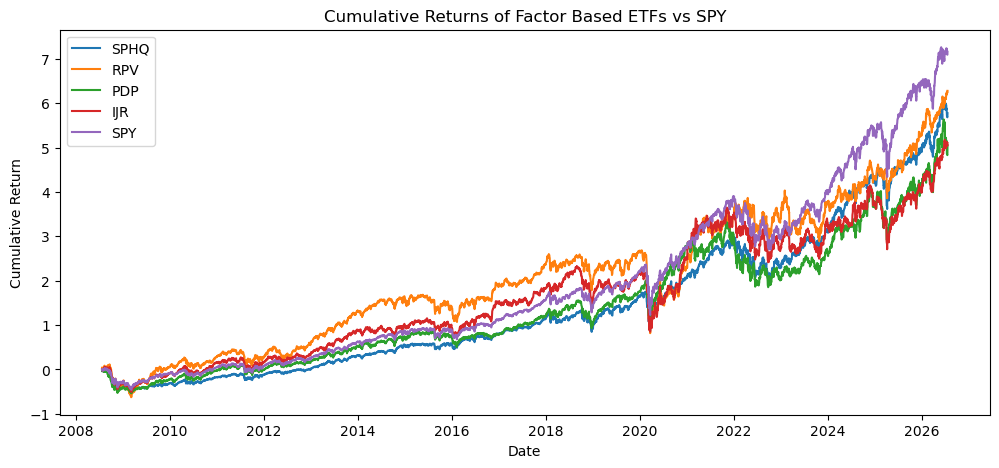

In [63]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

tickers = ["SPHQ", "RPV", "PDP","IJR", "SPY"]
etf_prices = yf.download(tickers, start="2008-07-22",end = "2026-07-22")['Close']
print(etf_prices)

returns = etf_prices.pct_change().dropna()
cumulative_returns = (1 + returns).cumprod() - 1
plt.figure(figsize=(12,5))
for ticker in tickers:
    plt.plot(cumulative_returns.index, cumulative_returns[ticker], label=ticker)
plt.title("Cumulative Returns of Factor Based ETFs vs SPY")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.show()
#Based on the information SPMO(Momentum ETF) has the highest cumulative return which outperforms the S&P 500 while VLUE comes close and QUAL underperforms a little

monthly_returns = (returns+1).resample('ME').prod() - 1
monthly_returns = monthly_returns.dropna()




In [46]:
total_returns = cumulative_returns.iloc[-1]

# Compare each ETF to SPY
outperformance = total_returns - total_returns["SPY"]

summary = pd.DataFrame({
    "Total Return": total_returns,
    "Outperformance vs SPY": outperformance
})

summary[summary["Outperformance vs SPY"] > 0]

,Total Return,Outperformance vs SPY
Ticker,,
SPMO,5.731405,2.300775


In [47]:
monthly_returns

Ticker,IJR,QUAL,SPMO,SPY,VLUE
Date,,,,,
2015-10-31,0.000000,0.041218,0.039301,0.031808,0.011476
2015-11-30,0.026979,0.004415,0.010313,0.003655,-0.006839
2015-12-31,-0.047356,-0.017171,-0.021159,-0.017282,-0.018702
2016-01-31,-0.061575,-0.046151,-0.039923,-0.049787,-0.086761
2016-02-29,0.010936,0.006007,-0.002019,-0.000826,0.018121
...,...,...,...,...,...
2026-03-31,-0.040043,-0.061701,-0.058951,-0.049380,-0.052945
2026-04-30,0.102888,0.080496,0.193382,0.105053,0.174977
2026-05-31,0.011378,0.039759,0.125570,0.052626,0.185850


In [41]:
from fredapi import Fred
fred = Fred(api_key='8928f3e001e93b5134ac408048a0f1b6')

cpi = fred.get_series("CPIAUCSL",
    observation_start="2010-07-22",
    observation_end="2026-07-22")

fed_funds = fred.get_series("FEDFUNDS",
    observation_start="2010-07-22",
    observation_end="2026-07-22"
)

macro = pd.DataFrame({
    'CPI': cpi,
    'Fed_Funds': fed_funds
})
macro.index = pd.to_datetime(macro.index)

macro



,CPI,Fed_Funds
2010-07-01,217.605,0.18
2010-08-01,217.923,0.19
2010-09-01,218.275,0.19
2010-10-01,219.035,0.19
2010-11-01,219.590,0.19
...,...,...
2026-02-01,327.460,3.64
2026-03-01,330.293,3.64
2026-04-01,332.407,3.64
2026-05-01,333.979,3.63


In [ ]:
factor_tickers = ["SPHQ", "RPV", "PDP", "IJR"]
macro['Fed_Funds_Change'] = macro['Fed_Funds'].diff(12) #Calculates change rather than levels
macro['Inflation (YoY)'] = macro['CPI'].pct_change(12) * 100
macro_known = macro[['Fed_Funds_Change','Inflation (YoY)','Fed_Funds']].shift(1)  #Shifts by 1 to avoid lookahead bias

macro_known.index = macro_known.index.to_period("M").to_timestamp("M")
monthly_returns.index = (
    monthly_returns.index.to_period("M").to_timestamp("M")
)

analysis_data = monthly_returns.join(
    macro_known,
    how="inner"
).dropna()

conditions = [analysis_data['Fed_Funds_Change'] > 0, analysis_data['Fed_Funds_Change'] < 0, analysis_data['Fed_Funds_Change'] == 0]
choices = ['Rising Rates','Falling Rates','Holding Rates']

#inflation_cutoff = analysis_data['Inflation (YoY)'].median()
#fed_fund_cutoff = analysis_data['Fed_Funds'].median()
analysis_data['Inflation_Direction'] = np.where(analysis_data['Inflation (YoY)'].diff() > 0, "High Inflation", "Low Inflation")
analysis_data['Fed_Funds_Direction'] = np.select(conditions,choices,default='Unkown')
analysis_data['Combined_Regime'] = analysis_data['Inflation_Direction'] + " / " + analysis_data['Fed_Funds_Direction']
analysis_data["Monthly_Risk_Free"] = (
    analysis_data["Fed_Funds"].shift(1) / 100 / 12
)

print(analysis_data)

def regime_statistics(group):
    r = group[factor_tickers]
    monthly_rf = group["Monthly_Risk_Free"]
    excess_returns = r.subtract(
        monthly_rf,
        axis=0
    )
    annualized_return = r.mean() * 12
    annualied_volatility = r.std() * np.sqrt(12)  #To annualize volatility it must be times sqrt(12)
    sharpe_ratio = (excess_returns.mean()/excess_returns.std())*np.sqrt(12)
    return pd.DataFrame({
        'Annualized Return': annualized_return,
        'Annualized Volatility': annualized_volatility,
        'Sharpe Ratio': sharpe_ratio
    })

regime_results = {}

for regime,group in analysis_data.groupby('Combined_Regime'):
    regime_results[regime] = regime_statistics(group)

#print(regime_results)

#for regime,result in regime_results.items():
    #print(f"{regime}:")
    #print(result)

                 IJR       PDP       RPV      SPHQ       SPY  \
2011-08-31 -0.077887 -0.054843 -0.065224 -0.041607 -0.054976   
2011-09-30 -0.103028 -0.095658 -0.076447 -0.054921 -0.069420   
2011-10-31  0.149128  0.097450  0.119937  0.102626  0.109147   
2011-11-30  0.006244  0.004565 -0.015098  0.007215 -0.004064   
2011-12-31  0.012611 -0.014760 -0.003734  0.009752  0.010448   
...              ...       ...       ...       ...       ...   
2026-02-28  0.021019  0.055574  0.047144  0.045872 -0.008642   
2026-03-31 -0.040043 -0.063813 -0.038306 -0.067508 -0.049380   
2026-04-30  0.102888  0.131025  0.035851  0.078335  0.105053   
2026-05-31  0.011378  0.045987  0.018429  0.052787  0.052626   
2026-06-30  0.072828  0.062237  0.010759  0.057945 -0.010293   

            Fed_Funds_Change  Inflation (YoY)  Fed_Funds Inflation_Direction  \
2011-08-31             -0.11         3.579881       0.07       Low Inflation   
2011-09-30             -0.09         3.754996       0.10      High Infl

C:\Users\rnana\AppData\Local\Temp\ipykernel_38984\1845384931.py:3: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  macro['Inflation (YoY)'] = macro['CPI'].pct_change(12) * 100
